In [1]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/datasets_TFM/df_final_preparado_3.parquet'
df_model = pd.read_parquet(path,engine='pyarrow')

In [3]:
df_model.head()

,pk_partition_year,pk_partition_month,entry_date_year,entry_date_month,pk_cid_n,age_n,salary_n,net_margin_n,region_code_cat_8.0,region_code_cat_15.0,...,securities_b,long_term_deposit_b,credit_card_b,payroll_b,pension_plan_b,payroll_account_b,emc_account_b,debit_card_b,em_account_p_b,em_acount_b
0,2018,1,2018,1,1375586.0,35.0,87218.101562,0.0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,1,2015,8,1050611.0,23.0,35548.738281,0.0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2018,1,2015,8,1050612.0,23.0,122179.109375,0.0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2018,1,2015,8,1050613.0,22.0,119775.539062,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2018,1,2015,8,1050614.0,23.0,88441.468750,0.0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5961849 entries, 0 to 5962923
Data columns (total 44 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   pk_partition_year               int16  
 1   pk_partition_month              int8   
 2   entry_date_year                 int16  
 3   entry_date_month                int8   
 4   pk_cid_n                        float32
 5   age_n                           float32
 6   salary_n                        float32
 7   net_margin_n                    float32
 8   region_code_cat_8.0             int8   
 9   region_code_cat_15.0            int8   
 10  region_code_cat_28.0            int8   
 11  region_code_cat_29.0            int8   
 12  region_code_cat_30.0            int8   
 13  region_code_cat_41.0            int8   
 14  region_code_cat_46.0            int8   
 15  region_code_cat_Otros           int8   
 16  entry_channel_cat_KAT           int8   
 17  entry_channel_cat_KFC           

PROPENSIÓN

La estrategía acá será: Hacer un analisis de las ventas de los productos para hacer una selección inteligente de sobre qué productos hacer la propension de ventas. Una vez selecionado los productos crearemos las variables target.
Pare determinar si el cliente compró el producto es necesario determinar el cambio de estado de "no lo tiene" a "lo tiene". Para ello es necesario ordenar el dataset mes y año (pk_partition_year y pk_partition_month)

Primer paso: Analisis de las ventas

In [5]:
# Volvemos a importar los df que habíamos borrado

df_sales = pd.read_csv('/content/drive/MyDrive/datasets_TFM/sales.csv')
df_product_desc = pd.read_csv('/content/drive/MyDrive/datasets_TFM/product_description.csv')


In [6]:
# Aseguramos el nombre de las llaves
if 'cid' in df_sales.columns:
    df_sales = df_sales.rename(columns={'cid': 'pk_cid'})
if 'product_ID' in df_sales.columns:
    df_sales = df_sales.rename(columns={'product_ID': 'pk_product_ID'})


--- TOP PRODUCTOS POR RENTABILIDAD ---
          product_desc  total_ventas  margen_total  pct_beneficio  \
1         pension_plan         19369   115757587.1      79.220973   
10           em_acount        117435     8217372.3       5.623720   
5   short_term_deposit          4441     6601241.5       4.517689   
6    long_term_deposit          4227     6327477.4       4.330333   
8           debit_card         38840     2330524.9       1.594940   
7           securities          1157     1732993.2       1.186008   
0                funds           880     1319161.5       0.902794   
2              payroll         18750     1311247.8       0.897378   
3      payroll_account         18110     1267134.7       0.867188   
11         emc_account         12323      862769.3       0.590453   

    margen_medio  
1    5976.435908  
10     69.973792  
5    1486.431322  
6    1496.919186  
8      60.003216  
7    1497.833362  
0    1499.047159  
2      69.933216  
3      69.968785  
11     70.0

/tmp/ipykernel_3079/536558125.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_product_analysis.head(7), x='product_desc', y='margen_total', palette='magma')


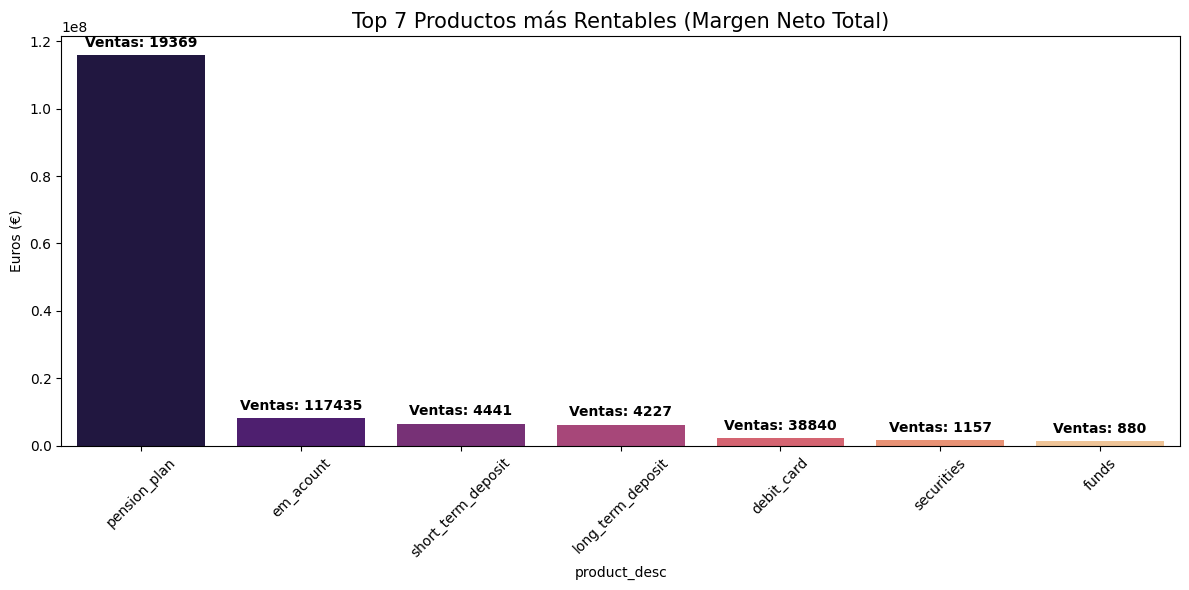

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agregamos las ventas por producto

df_product_analysis = df_sales.groupby('pk_product_ID').agg(
    total_ventas=('pk_cid', 'count'),
    margen_total=('net_margin', 'sum'),
    margen_medio=('net_margin', 'mean')
).reset_index()

# 2. Traemos el nombre del producto para que sea legible
df_product_analysis = pd.merge(df_product_analysis, df_product_desc, on='pk_product_ID', how='left')

# 3. Calculamos el % de contribución al beneficio total
total_profit = df_product_analysis['margen_total'].sum()
df_product_analysis['pct_beneficio'] = (df_product_analysis['margen_total'] / total_profit) * 100

# 4. Ordenamos por Margen Total
df_product_analysis = df_product_analysis.sort_values(by='margen_total', ascending=False)

print("--- TOP PRODUCTOS POR RENTABILIDAD ---")
print(df_product_analysis[['product_desc', 'total_ventas', 'margen_total', 'pct_beneficio','margen_medio']].head(10))

# Guardamos el margen por unidad de producto para el top 4 de productos
df_top_4_margen_por_unidad = df_product_analysis.head(4)[['pk_product_ID','product_desc','margen_medio']]

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))

# Gráfico de Barras: Volumen vs Margen
ax = sns.barplot(data=df_product_analysis.head(7), x='product_desc', y='margen_total', palette='magma')
plt.title('Top 7 Productos más Rentables (Margen Neto Total)', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Euros (€)')

# Añadimos etiquetas de volumen sobre las barras
for i, p in enumerate(ax.patches):
    ax.annotate(f"Ventas: {df_product_analysis.iloc[i]['total_ventas']}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Elegimos el Top 4 de los productos mas rentables para la compañia: pension:_plan, em_acount, short_term_deposit y long_term_deposit. Estos representan el 93,7% aprox. del margen total.

Dado que el producto pension_plan representa el 79% del maren total, este será nuestro target principal.

In [8]:
import gc

del df_product_analysis
gc.collect()


167

In [9]:
import pandas as pd
import numpy as np

# 1. Definimos los productos elegidos
productos_target = ['pension_plan_b', 'em_acount_b', 'short_term_deposit_b', 'long_term_deposit_b']

# 2. ORDEN CRÍTICO: Ordenamos por cliente y fecha cronológicamente

df_model = df_model.sort_values(by=['pk_cid_n', 'pk_partition_year', 'pk_partition_month'])

# 3. Bucle para crear los targets de altas (0 -> 1)
print("Calculando altas de productos...")
for prod in productos_target:
    # Calculamos la diferencia con el mes anterior
    # Si pasó de no tenerlo (0) a tenerlo (1), la diferencia es 1
    df_model[f'target_{prod}'] = df_model.groupby('pk_cid_n')[prod].diff()

    # Limpiamos: Solo nos importan los 1s (nuevas compras). El resto (bajas o mantenimiento) es 0.
    df_model[f'target_{prod}'] = df_model[f'target_{prod}'].apply(lambda x: 1 if x == 1 else 0)

    # Imprimimos el resultado para verificar
    total_altas = df_model[f'target_{prod}'].sum()
    print(f"Total de nuevas altas para {prod}: {total_altas}")



Calculando altas de productos...
Total de nuevas altas para pension_plan_b: 36855
Total de nuevas altas para em_acount_b: 40926
Total de nuevas altas para short_term_deposit_b: 2565
Total de nuevas altas para long_term_deposit_b: 3997


In [10]:
# 4. Feature Engineering: Crear los 'Lags'
# Usamos datos del mes T-1 para predecir el mes T
features_base = [

    #variables de cliente
    'age_n',
    'salary_n',
    'gender_b',
    'segment_cat_02 - PARTICULARES',
    'segment_cat_03 - UNIVERSITARIO',
    'active_customer_b',
    'segment_cat_Other',
    'segment_cat_01 - TOP',
    'entry_channel_cat_KAT',
    'entry_channel_cat_KFC',
    'entry_channel_cat_KHE',
    'entry_channel_cat_KHK',
    'entry_channel_cat_KHQ',
    'entry_channel_cat_Otros',

    'region_code_cat_8.0',
    'region_code_cat_15.0',
    'region_code_cat_28.0',
    'region_code_cat_29.0',
    'region_code_cat_30.0',
    'region_code_cat_41.0',
    'region_code_cat_46.0',
    'region_code_cat_Otros',

    #Variables Productos
    'short_term_deposit_b',
    'loans_b',
    'mortgage_b',
    'funds_b',
    'securities_b',
    'long_term_deposit_b',
    'credit_card_b',
    'payroll_b',
    'pension_plan_b',
    'payroll_account_b',
    'emc_account_b',
    'debit_card_b',
    'em_account_p_b',
    'em_acount_b'

    ]

for col in features_base:
    df_model[f'{col}_lag1'] = df_model.groupby('pk_cid_n')[col].shift(1)

# Eliminamos las filas donde no hay lag (el primer mes de cada cliente, Enero 2018)
df_ml = df_model.dropna(subset=[f'{features_base[0]}_lag1']).copy()

In [11]:
df_ml

,pk_partition_year,pk_partition_month,entry_date_year,entry_date_month,pk_cid_n,age_n,salary_n,net_margin_n,region_code_cat_8.0,region_code_cat_15.0,...,securities_b_lag1,long_term_deposit_b_lag1,credit_card_b_lag1,payroll_b_lag1,pension_plan_b_lag1,payroll_account_b_lag1,emc_account_b_lag1,debit_card_b_lag1,em_account_p_b_lag1,em_acount_b_lag1
2168122,2018,8,2018,7,15891.0,59.0,88441.46875,0.000000,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3628236,2018,12,2018,11,16063.0,62.0,88441.46875,0.000000,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4028169,2019,1,2018,11,16063.0,62.0,88441.46875,0.000000,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4480637,2019,2,2018,11,16063.0,62.0,88441.46875,0.000000,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4876040,2019,3,2018,11,16063.0,62.0,88441.46875,0.000000,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5682992,2019,5,2019,4,1548202.0,22.0,88441.46875,73.800003,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5682991,2019,5,2019,4,1548203.0,51.0,88441.46875,69.199997,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5682990,2019,5,2019,4,1548204.0,54.0,88441.46875,0.000000,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5682989,2019,5,2019,4,1548206.0,40.0,88441.46875,0.000000,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Eliminamos los DF que ya no necesitamos para liberar memoria

In [12]:
import gc

# Elimina tablas pesadas que ya procesaste
del df_model

# Forzar al recolector de basura a limpiar la RAM
gc.collect()

0

Primero separamos los sets de Train, Validation y Test. Se elige el últimomes para el Test y penultimo para el ValidationAnalizamos qué variables son las mas relevantes en el dataset para el modelo de cada target. Aplicamos un Random Forest para determinar la importancia de las variables para cada target.

In [13]:
# Separamos la data de Train, Validation y Test. Escogemos el ultimo mes como data para test.

train_data = df_ml[
    ((df_ml['pk_partition_month'] < 4) &
    (df_ml['pk_partition_year'] == 2019)) |
    (df_ml['pk_partition_year'] == 2018)
]

val_data = df_ml[
    (df_ml['pk_partition_month'] == 5) &
    (df_ml['pk_partition_year'] == 2019)
]
test_data = df_ml[
    (df_ml['pk_partition_month'] == 4) &
    (df_ml['pk_partition_year'] == 2019)
]

In [14]:
# 1. Definimos cuál es el Target que vas a entrenar en esta pasada
productos_target_model = ['target_pension_plan_b', 'target_em_acount_b', 'target_short_term_deposit_b', 'target_long_term_deposit_b']

# 2. Identificamos SOLO las columnas que son 'Lags'
columnas_lag = [col for col in df_ml.columns if col.endswith('_lag1')]

variables_predictoras = columnas_lag # Usamos solo lags según pediste

# 3. Creamos la lista definitiva: pk_cid + Target + Predictores
columnas_a_mantener = ['pk_cid_n'] + productos_target_model + variables_predictoras

In [15]:
# 4. Creamos el Dataframe "Quirúrgico"
# Usamos .copy() para crear un nuevo objeto en memoria y poder borrar el anterior
train_data_limpio = train_data[columnas_a_mantener].copy()
#del train_data
#gc.collect()
test_data_limpio = test_data[columnas_a_mantener].copy()
#del test_data
#gc.collect()
val_data_limpio = val_data[columnas_a_mantener].copy()
#del val_data
#gc.collect()

# 5. ¡EL PASO SALVAVIDAS PARA LA RAM!
# Eliminamos el df_train original gigante y forzamos el vaciado de basura de Python
# del df_ml
del train_data
del test_data
del val_data
gc.collect()

#print(f"Tamaño del nuevo df_train_limpio en RAM: {df_limpio.memory_usage().sum() / 1e6:.2f} MB")
#print(f"Columnas listas para entrenar: {df_limpio.shape[1]}")

# 6. Separamos X (Features) e Y (Target) para el modelo
#X_train = df_limpio.drop(columns=[target_actual])
#y_train = df_limpio[target_actual]

# (Si ya no necesitas df_train_limpio porque ya tienes X_train e y_train, bórralo también)
#del df_limpio
#gc.collect()

0

In [16]:
train_data_limpio.shape

(4632191, 41)

In [17]:
test_data_limpio.shape

(434962, 41)

In [18]:
productos_target = ['pension_plan_b', 'em_acount_b', 'short_term_deposit_b', 'long_term_deposit_b']


Usamos un Random Forest para detectar las variables mas importantes específicas para cada producto target. Luego entrenamos el modelo para cada target con el top 7 de variables mas importantes en cada caso. Mostramos las estadisticas del modelo, matriz de confusion y curva ROC-AUC. Además vemos con SHARP el analisis de las variables mas influyentes. Y finalmente el listado top 10 de clientes a contactar con mayor probabilidad de comprar el producto, y el top 1% (cantidad) de clientes potenciales para cada producto.


 Entrenando y Evaluando Modelo para: pension_plan_b
Top 7 variables motivadoras reales: ['payroll_account_b_lag1', 'active_customer_b_lag1', 'debit_card_b_lag1', 'age_n_lag1', 'em_acount_b_lag1', 'segment_cat_03 - UNIVERSITARIO_lag1', 'entry_channel_cat_KHE_lag1']


/tmp/ipykernel_3079/3088457023.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia.head(7), x='Importancia', y='Variable', palette='viridis')


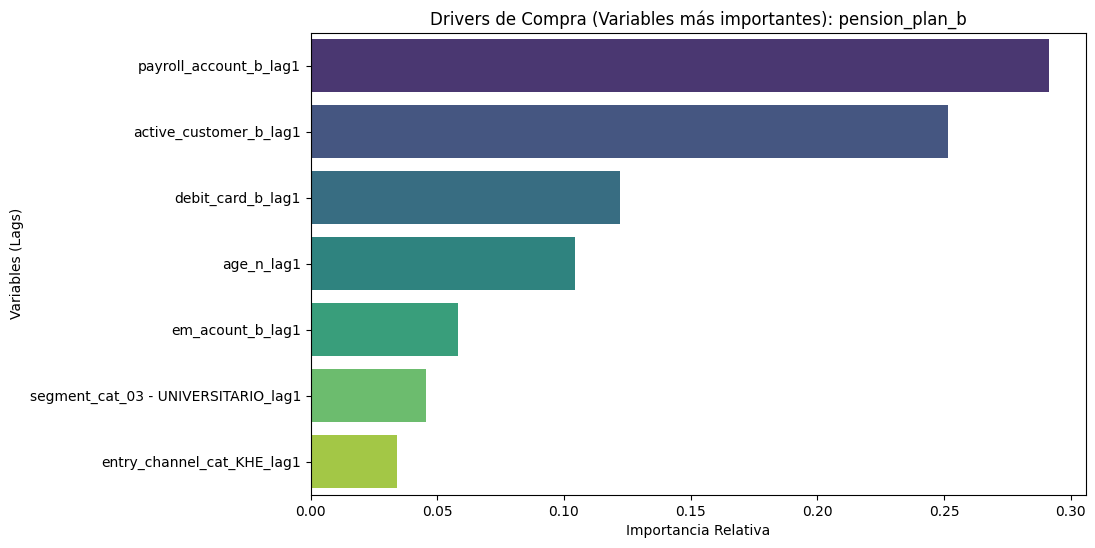


>>> REPORTE DE CLASIFICACIÓN <<<
              precision    recall  f1-score   support

   No Compra       1.00      0.83      0.90    416719
      Compra       0.02      0.81      0.05      2274

    accuracy                           0.83    418993
   macro avg       0.51      0.82      0.48    418993
weighted avg       0.99      0.83      0.90    418993



<Figure size 640x480 with 0 Axes>

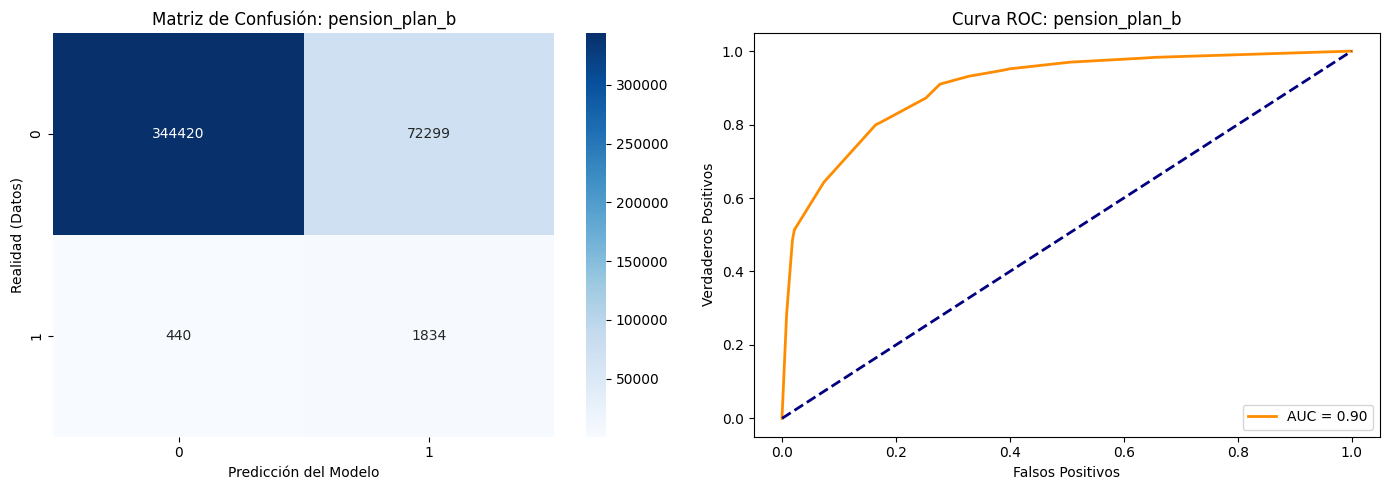

Calculando SHAP Values (esto puede tardar unos segundos)...
Shape of shap_values: (418993, 7, 2)
Shape of shap_values_clase_compra: (418993, 7)


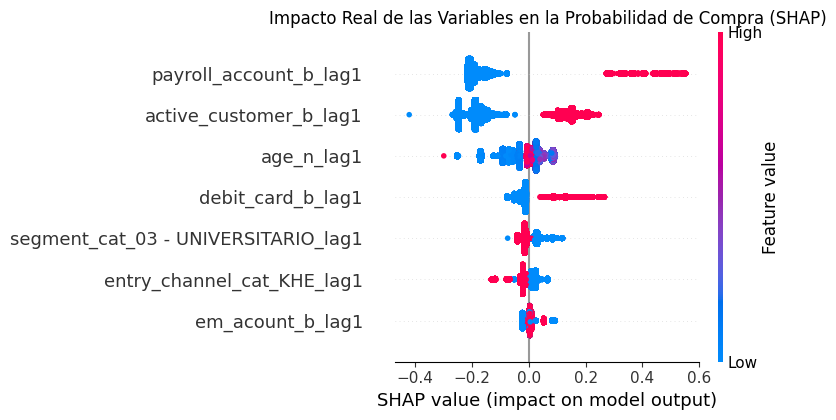

--- SIMULACIÓN DE CONVERSIÓN BASADA EN ABRIL 2019 ---
Total de clientes evaluados: 422161
Total de clientes en el Top 5.0%: 21108
Compras reales dentro de ese Top: 1730
TASA DE CONVERSIÓN REAL DEL SEGMENTO: 8.20%

 Entrenando y Evaluando Modelo para: em_acount_b
Top 7 variables motivadoras reales: ['segment_cat_Other_lag1', 'pension_plan_b_lag1', 'active_customer_b_lag1', 'payroll_b_lag1', 'entry_channel_cat_KHE_lag1', 'segment_cat_02 - PARTICULARES_lag1', 'segment_cat_03 - UNIVERSITARIO_lag1']


/tmp/ipykernel_3079/3088457023.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia.head(7), x='Importancia', y='Variable', palette='viridis')


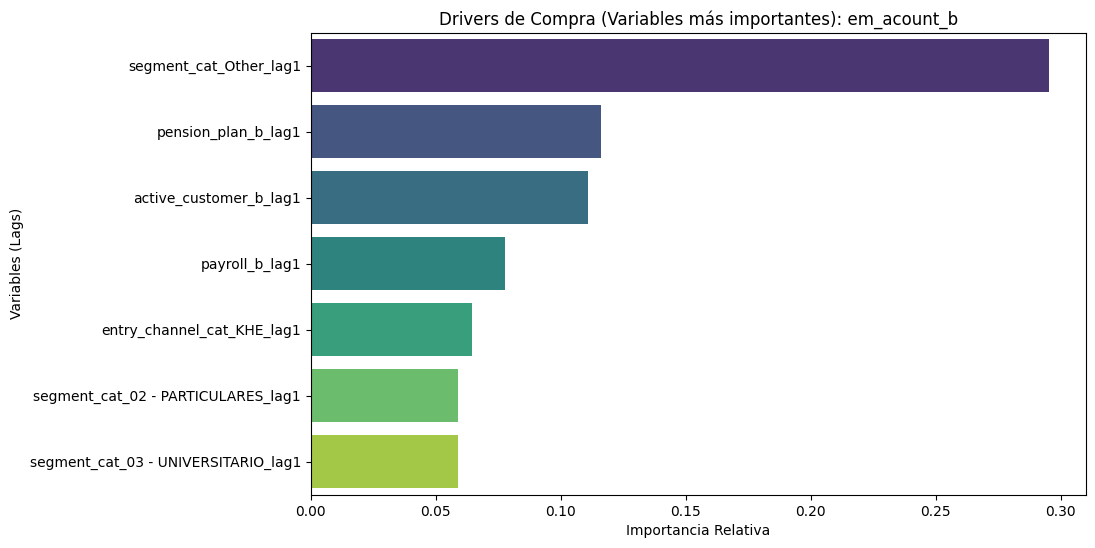


>>> REPORTE DE CLASIFICACIÓN <<<
              precision    recall  f1-score   support

   No Compra       0.99      0.85      0.92    137392
      Compra       0.08      0.71      0.15      2580

    accuracy                           0.85    139972
   macro avg       0.54      0.78      0.53    139972
weighted avg       0.98      0.85      0.90    139972



<Figure size 640x480 with 0 Axes>

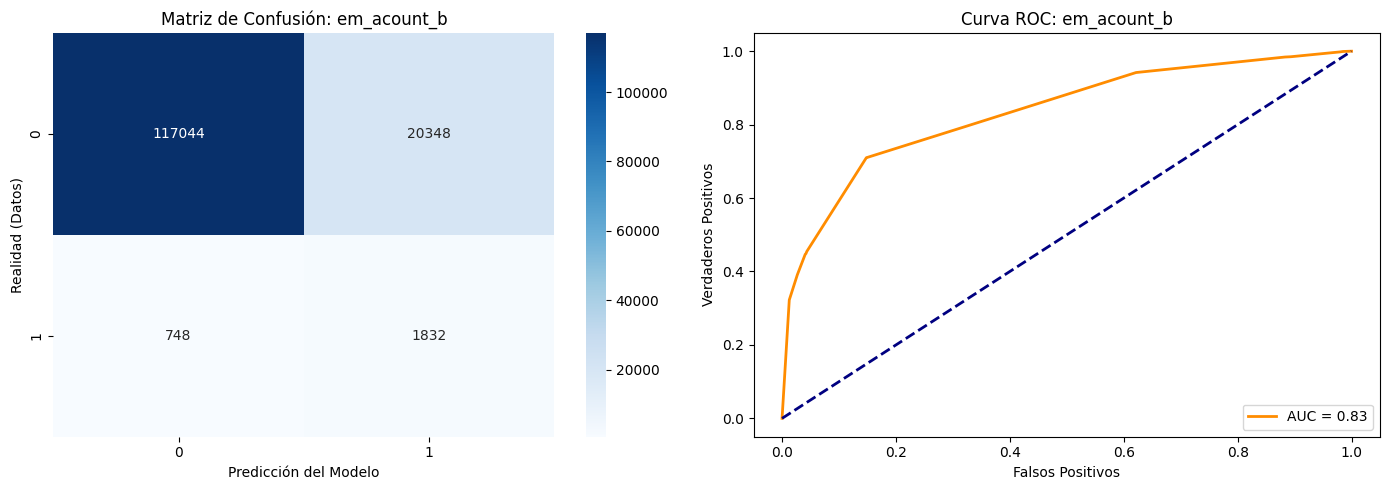

Calculando SHAP Values (esto puede tardar unos segundos)...
Shape of shap_values: (139972, 7, 2)
Shape of shap_values_clase_compra: (139972, 7)


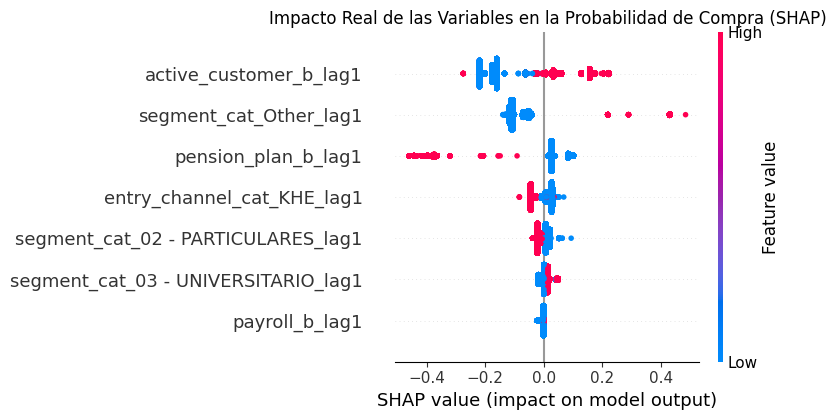

--- SIMULACIÓN DE CONVERSIÓN BASADA EN ABRIL 2019 ---
Total de clientes evaluados: 142598
Total de clientes en el Top 5.0%: 7129
Compras reales dentro de ese Top: 1103
TASA DE CONVERSIÓN REAL DEL SEGMENTO: 15.47%

 Entrenando y Evaluando Modelo para: short_term_deposit_b
⚠️ No hay clientes suficientes en el target short_term_deposit_b. Saltando...

 Entrenando y Evaluando Modelo para: long_term_deposit_b
Top 7 variables motivadoras reales: ['age_n_lag1', 'segment_cat_03 - UNIVERSITARIO_lag1', 'entry_channel_cat_KHE_lag1', 'active_customer_b_lag1', 'segment_cat_01 - TOP_lag1', 'segment_cat_02 - PARTICULARES_lag1', 'short_term_deposit_b_lag1']


/tmp/ipykernel_3079/3088457023.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia.head(7), x='Importancia', y='Variable', palette='viridis')


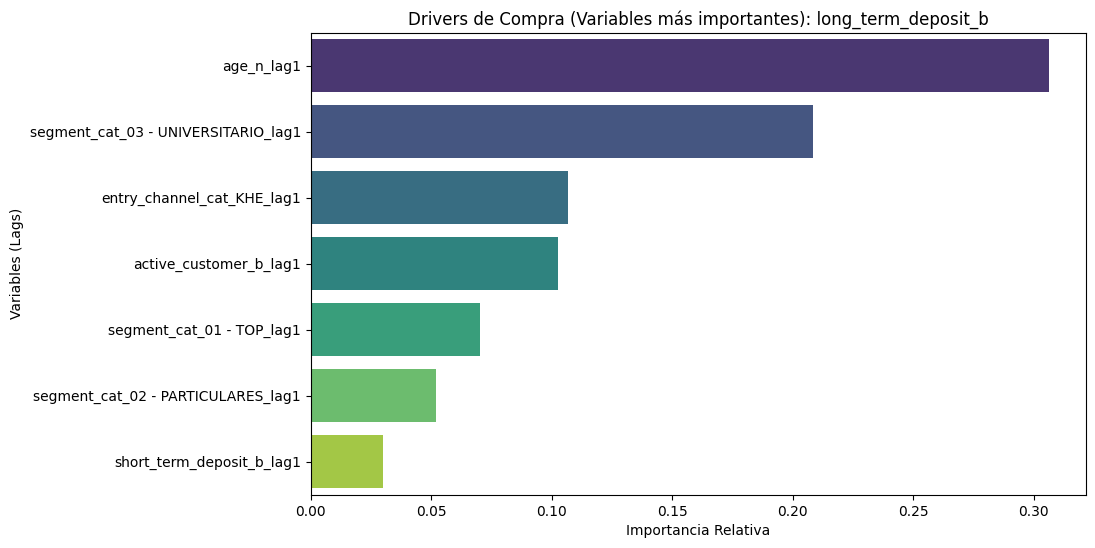


>>> REPORTE DE CLASIFICACIÓN <<<
              precision    recall  f1-score   support

   No Compra       1.00      0.80      0.89    428410
      Compra       0.00      1.00      0.00        26

    accuracy                           0.80    428436
   macro avg       0.50      0.90      0.44    428436
weighted avg       1.00      0.80      0.89    428436



<Figure size 640x480 with 0 Axes>

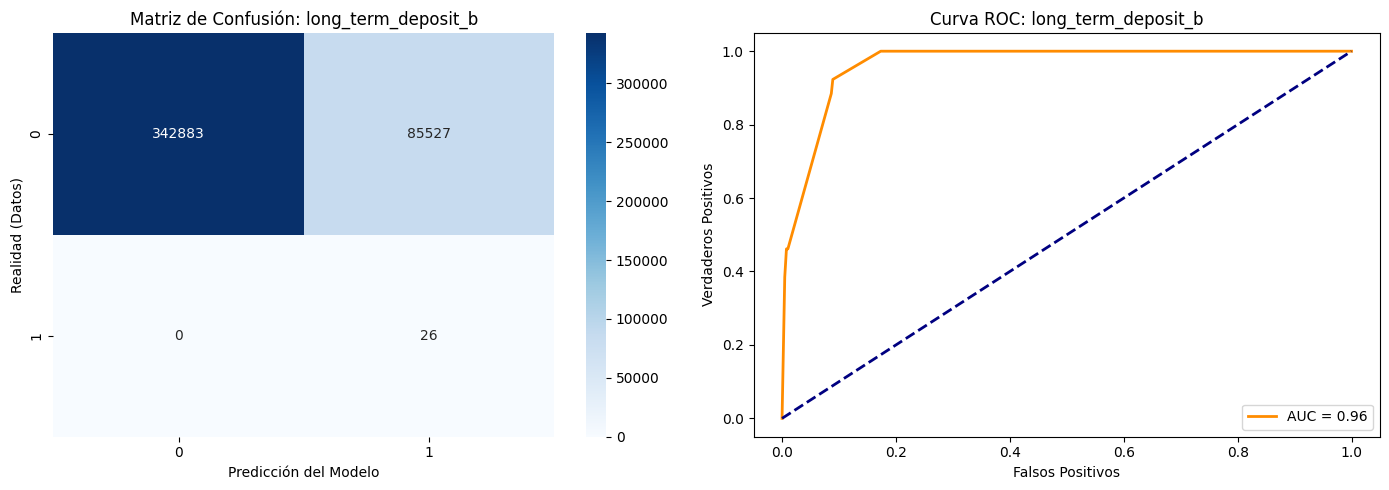

Calculando SHAP Values (esto puede tardar unos segundos)...
Shape of shap_values: (428436, 7, 2)
Shape of shap_values_clase_compra: (428436, 7)


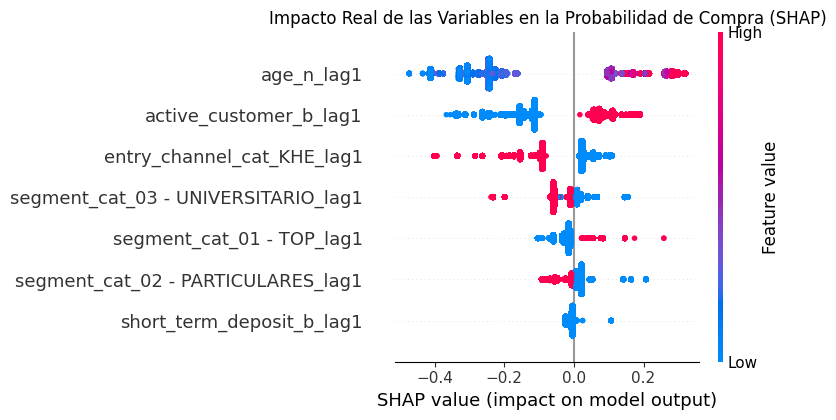

--- SIMULACIÓN DE CONVERSIÓN BASADA EN ABRIL 2019 ---
Total de clientes evaluados: 432021
Total de clientes en el Top 5.0%: 21601
Compras reales dentro de ese Top: 3
TASA DE CONVERSIÓN REAL DEL SEGMENTO: 0.01%


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shap

# 1. Asegurarnos de tener los features correctos
features_totales = [col for col in df_ml.columns if 'lag1' in col]
resultados_modelos = {}

# 2. El Bucle Maestro
for prod in productos_target:
    target_col = f'target_{prod}'
    lag_del_producto = f'{prod}_lag1'

    print(f"\n" + "="*50)
    print(f" Entrenando y Evaluando Modelo para: {prod}")
    print(f"="*50)

    # --- FILTRO DEL UNIVERSO (Solo los elegibles) ---
    universo_train = train_data_limpio[train_data_limpio[lag_del_producto] == 0].copy()
    universo_test  = test_data_limpio[test_data_limpio[lag_del_producto] == 0].copy()
    universo_val  = val_data_limpio[val_data_limpio[lag_del_producto] == 0].copy()

    # SEGURO ANTI-ERRORES: Comprobamos que haya datos antes de modelar
    if len(universo_train) == 0 or len(universo_test) == 0:
        print(f"⚠️ No hay clientes suficientes en el target {prod}. Saltando...")
        continue

    features_a_usar = [f for f in features_totales if f != lag_del_producto]

    # Separamos X e Y asegurando que tengan la misma longitud
    y_train = universo_train[target_col]
    y_test  = universo_test[target_col]
    y_val  = universo_val[target_col]

    if y_train.sum() == 0 or y_test.sum() == 0:
        print(f"⚠️ No hay clientes suficientes en el target {prod}. Saltando...")
        continue

    X_train_full = universo_train[features_a_usar]
    X_test_full  = universo_test[features_a_usar]
    X_val_full  = universo_val[features_a_usar]

    # --- FASE 1: FEATURE SELECTION ---
    rf_selector = RandomForestClassifier(n_estimators=50, max_depth=5, class_weight='balanced', random_state=42)
    rf_selector.fit(X_train_full, y_train)

    df_importancia = pd.DataFrame({'Variable': features_a_usar, 'Importancia': rf_selector.feature_importances_})
    df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)
    top_7_features = df_importancia.head(7)['Variable'].tolist()

    print(f"Top 7 variables motivadoras reales: {top_7_features}")


    # --- FASE 2: ENTRENAMIENTO DEL ÁRBOL --- MODELO PRINCIPAL
    X_train_opt = X_train_full[top_7_features]
    X_test_opt  = X_test_full[top_7_features]
    X_val_opt  = X_val_full[top_7_features]

    arbol_modelo = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    arbol_modelo.fit(X_train_opt, y_train)

    y_pred = arbol_modelo.predict(X_test_opt)
    y_proba = arbol_modelo.predict_proba(X_test_opt)[:, 1]


    # Visualización de top variables por Target

# FORZAR UNA FIGURA NUEVA: Esto evita que los gráficos se mezclen
    plt.figure(figsize=(10, 6))

    sns.barplot(data=df_importancia.head(7), x='Importancia', y='Variable', palette='viridis')
    plt.title(f'Drivers de Compra (Variables más importantes): {prod}')
    plt.xlabel('Importancia Relativa')
    plt.ylabel('Variables (Lags)')

    # MOSTRAR LA GRÁFICA
    plt.show()

    # LIMPIAR MEMORIA
    plt.close()


    # --- FASE 3: MÉTRICAS Y VISUALIZACIÓN ---
    print("\n>>> REPORTE DE CLASIFICACIÓN <<<")
    print(classification_report(y_test, y_pred, target_names=['No Compra', 'Compra']))

    # Limpiamos el lienzo para que no se superpongan gráficos
    plt.clf()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico A: Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión: {prod}')
    axes[0].set_xlabel('Predicción del Modelo')
    axes[0].set_ylabel('Realidad (Datos)')

    # Gráfico B: Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title(f'Curva ROC: {prod}')
    axes[1].set_xlabel('Falsos Positivos')
    axes[1].set_ylabel('Verdaderos Positivos')
    axes[1].legend(loc="lower right")

    # Renderizamos y liberamos memoria
    plt.tight_layout()
    plt.show()
    plt.pause(0.1)
    plt.close(fig)

    # Guardamos los modelos para cada producto target
    resultados_modelos[prod] = {'modelo': arbol_modelo, 'features': top_7_features, 'auc': roc_auc}



#### Calculo de SHAP para visualizar la influencia de cada variable relevante en el modelo

    print("Calculando SHAP Values (esto puede tardar unos segundos)...")

# Creamos el explicador SHAP para modelos de árboles
    explainer = shap.TreeExplainer(arbol_modelo)
    shap_values = explainer.shap_values(X_test_opt)

    print(f"Shape of shap_values: {shap_values.shape}")

    # SHAP devuelve una lista con los valores para la clase 0 y la clase 1.
    # Nos interesa la clase 1 (Propensión a Compra)
    # If shap_values is a list of arrays (common for multi-output), shap_values[1] is correct.
    # If shap_values is a 3D numpy array of shape (n_samples, n_features, n_classes) as observed in kernel state:
    if isinstance(shap_values, list):
        shap_values_clase_compra = shap_values[1]
    else: # Assume it's a 3D numpy array of shape (n_samples, n_features, n_classes)
        shap_values_clase_compra = shap_values[:, :, 1] # Corrected slicing for all features of class 1

    print(f"Shape of shap_values_clase_compra: {shap_values_clase_compra.shape}")
    # Dibujamos el gráfico resumen (Summary Plot)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_clase_compra, X_test_opt, show=False)
    plt.title("Impacto Real de las Variables en la Probabilidad de Compra (SHAP)")
    plt.tight_layout()
    plt.show()


# Calculamos la tasa de conversión real por cada producto target.
# La necesitaremos para calcular la probabilidad real de compra y la proyección de ventas
# Usamos el set de validación correspondiente a Mayo 2019 (datos de Abril 2019 por la aplicación de LAG)

    y_val_proba = arbol_modelo.predict_proba(X_val_opt)[:, 1]

    df_simulacion = pd.DataFrame({
        'pk_cid_n': universo_val['pk_cid_n'],
        'score_modelo': y_val_proba,
        'compra_real': y_val.values # Esto es 1 si compró en la realidad, 0 si no
    })

# Ordenamos por probabilidad del modelo
    df_simulacion = df_simulacion.sort_values(by='score_modelo', ascending=False)

#Seleccionamos a nuestro "Público Objetivo" (ej. El Top 5% de la base)
    top_5_porciento = 0.05
    volumen_top = int(len(df_simulacion) * top_5_porciento)

    clientes_top = df_simulacion.head(volumen_top)

# EL CÁLCULO DE LA TASA REAL
# Sumamos cuántas compras reales hubo en ese grupo Top y lo dividimos por el total del grupo
    compras_en_el_top = clientes_top['compra_real'].sum()
    tasa_conversion_real = compras_en_el_top / volumen_top

    print(f"--- SIMULACIÓN DE CONVERSIÓN BASADA EN ABRIL 2019 ---")
    print(f"Total de clientes evaluados: {len(df_simulacion)}")
    print(f"Total de clientes en el Top {top_5_porciento*100}%: {volumen_top}")
    print(f"Compras reales dentro de ese Top: {compras_en_el_top}")
    print(f"TASA DE CONVERSIÓN REAL DEL SEGMENTO: {tasa_conversion_real * 100:.2f}%")


    resultados_modelos[prod]['tasa_conversion_real'] = tasa_conversion_real
    resultados_modelos[prod]['df_simulacion'] = df_simulacion


Ahora que tenemos los modelos listos para cada producto, analizamos como se comportan para decidir finalmente con cuales quedarnos. En este caso, dado que la tasa de conversion del producto taget "long_term_deposit" es mnuy baja, podemos descartar ese target. De igual forma descartamos el producto target "short_term_deposit" ya que no se puede evaluar de forma correcta porque no hay altas suficientes en el set de test ni validation. Finalmente los productos elegidos son: pension_plan como principal y em_account como secundario (valor agregado)


In [20]:
productos_target

['pension_plan_b',
 'em_acount_b',
 'short_term_deposit_b',
 'long_term_deposit_b']

In [21]:
# Dado que la tasa de conversion del producto taget "long_term_deposit" es mnuy baja, podemos descartar ese target.
# De igual forma descartamos el producto target "short_term_deposit" ya que no se puede evaluar porque no hay altas suficientes en el set de test
productos_target.remove('short_term_deposit_b')
productos_target.remove('long_term_deposit_b')

# Borramos los modelos de los productos que descartamos
del resultados_modelos['long_term_deposit_b']



In [22]:
# Usamos esta lista con este formato para evitar errores por cambio de nombre en las variables originales
# para poder usar los cálculo iniciales de margent medio por producto
productos_target_2 = ['pension_plan', 'em_acount']

Procedemos al cálculo de la proyección de potenciales clientes para la campaña de Junio 2019, se muestra el top 10 de clientes, pero se escoge el top 5% de clientes por producto para la campaña. Luego con la Tasa de Conversión calculada anteriormente por cada producto target, se obtiene el volumen final proyectado de clientes que adquirirían el producto.

Finalmente se obtiene el Margen de Ingreso proyectado por cada producto basado en la propensión de clientes.

In [23]:
# Procedemos al cálculo de la proyección de potenciales clientes para la campaña de Junio 2019
# Rescatamos la data del mes de mayo 2019 antes de hacer el LAG, para realizar una predicción para le mes de Junio 2019.
# Usamos solo los features base para la predicción de probabilidad

columnas_proyeccion = ['pk_cid_n'] + features_base
df_mayo_2019 = df_ml[(df_ml['pk_partition_month']== 5) & (df_ml['pk_partition_year'] == 2019)][columnas_proyeccion].copy()

# Creamos las columnas LAG (sin hacer shift, solo nos quedamos con el nombre) para poder usarlas en el modelo
for col in features_base:
  if col in df_mayo_2019.columns:
    df_mayo_2019[f'{col}_lag1'] = df_mayo_2019[col]


for prod in productos_target_2:
  df_scoring_elegibles = df_mayo_2019[df_mayo_2019[f'{prod}_b_lag1'] == 0].copy()
  X_scoring = df_scoring_elegibles[resultados_modelos[f'{prod}_b']['features']]
  proba_proyectado = resultados_modelos[f'{prod}_b']['modelo'].predict_proba(X_scoring)[:, 1]
  predict_proyectado = resultados_modelos[f'{prod}_b']['modelo'].predict(X_scoring)

  resultado_proyeccion= pd.DataFrame ({
      'pk_cid_n': df_scoring_elegibles['pk_cid_n'],
      'probabilidad_compra': proba_proyectado
  })
  resultado_proyeccion = resultado_proyeccion.sort_values(by='probabilidad_compra', ascending=False)

  print(f"\n--- TOP 10 CLIENTES A CONTACTAR JUNIO 2019 PARA {prod} ---")
  print(resultado_proyeccion['pk_cid_n'].head(10))

# Guardamos los resultados de la proyección
  resultados_modelos[f'{prod}_b']['df_proyeccion'] = resultado_proyeccion
  resultados_modelos[f'{prod}_b']['prediccion'] = predict_proyectado

  #Seleccionamos a nuestro "Público Objetivo" como El Top 5% de la base
  top_5_porciento = 0.05
  volumen_top = int(len(resultados_modelos[f'{prod}_b']['df_proyeccion']) * top_5_porciento)

  # Calculamos la proyección de ingreso en base a la tasa de conversión de cada modelo

  tasa_conversion = round(resultados_modelos[f'{prod}_b']['tasa_conversion_real'],4)

  volumen_proyectado = round(volumen_top * resultados_modelos[f'{prod}_b']['tasa_conversion_real'])

  ingreso_proyectado = volumen_proyectado * round(df_top_4_margen_por_unidad[df_top_4_margen_por_unidad['product_desc'] == prod]['margen_medio'].item(),2)

  print(f"--- PROYECCIÓN DE INGRESO PARA {prod} EN JUNIO 2019")
  print(f"Total de clientes en el Top {top_5_porciento*100}%: {volumen_top}")
  print(f"Total de clientes proyectados en base a Tasa de Conversión {round(tasa_conversion*100,2)}%: {volumen_proyectado}")
  print(f"Ingreso proyectado: ${ingreso_proyectado}")




--- TOP 10 CLIENTES A CONTACTAR JUNIO 2019 PARA pension_plan ---
5902458    1232895.0
5523275      60679.0
5781273    1060788.0
5897901    1239229.0
5929481    1135952.0
5834588    1014378.0
5636715    1318096.0
5933656    1127188.0
5537430    1365348.0
5562621    1408695.0
Name: pk_cid_n, dtype: float32
--- PROYECCIÓN DE INGRESO PARA pension_plan EN JUNIO 2019
Total de clientes en el Top 5.0%: 21052
Total de clientes proyectados en base a Tasa de Conversión 8.2%: 1725
Ingreso proyectado: $10309359.0

--- TOP 10 CLIENTES A CONTACTAR JUNIO 2019 PARA em_acount ---
5700227    1436378.0
5676115    1537676.0
5844078    1014811.0
5559332    1395883.0
5523068     246911.0
5673697    1542008.0
5755751    1459746.0
5745144    1455448.0
5831980    1011278.0
5529602    1353608.0
Name: pk_cid_n, dtype: float32
--- PROYECCIÓN DE INGRESO PARA em_acount EN JUNIO 2019
Total de clientes en el Top 5.0%: 7180
Total de clientes proyectados en base a Tasa de Conversión 15.47%: 1111
Ingreso proyectado: $77

In [27]:
resultados_modelos['pension_plan_b']['prediccion'].sum()

np.int64(77015)

In [29]:
resultados_modelos['em_acount_b']['prediccion'].sum()

np.int64(20826)

Importamos el Dataset de los Cluster para realizar el cruce con la prediccion del top 5% para el producto pension_plan

In [51]:
path_2 = '/content/drive/MyDrive/datasets_TFM/df_cluster_1.parquet'
df_cluster = pd.read_parquet(path_2,engine='pyarrow')

In [52]:
df_cluster.shape

(171514, 50)

In [53]:
df_top_pension_plan = resultados_modelos['pension_plan_b']['df_proyeccion'].merge(df_cluster, on='pk_cid_n', how='left')

In [54]:
df_top_pension_plan = df_top_pension_plan.head(21052)

In [60]:
df_top_pension_plan.head()

,pk_cid_n,probabilidad_compra,pk_partition_year,pk_partition_month,entry_date_year,entry_date_month,age_n,salary_n,net_margin_n,region_code_cat_8.0,...,emc_account_b,debit_card_b,em_account_p_b,em_acount_b,cluster_5,cluster_7,cluster_8,cluster_name,cluster,cluster_kmeans
0,1232895.0,0.997623,2019.0,5.0,2016.0,12.0,81.0,88441.468750,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,2.0,Clientes nómina de alta vinculación,3.0,1.0
1,60679.0,0.997623,2019.0,5.0,2016.0,11.0,82.0,231522.750000,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,2.0,Clientes nómina de alta vinculación,3.0,1.0
2,1060788.0,0.997623,2019.0,5.0,2015.0,9.0,90.0,160648.234375,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,2.0,Clientes nómina de alta vinculación,3.0,1.0
3,1239229.0,0.997623,2019.0,5.0,2017.0,1.0,84.0,88441.468750,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,2.0,Clientes nómina de alta vinculación,3.0,1.0
4,1135952.0,0.997623,2019.0,5.0,2016.0,5.0,77.0,136322.312500,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,2.0,Clientes nómina de alta vinculación,3.0,1.0


In [61]:
df_top_pension_plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21052 entries, 0 to 21051
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   pk_cid_n                        21052 non-null  float32
 1   probabilidad_compra             21052 non-null  float64
 2   pk_partition_year               20272 non-null  float64
 3   pk_partition_month              20272 non-null  float64
 4   entry_date_year                 20272 non-null  float64
 5   entry_date_month                20272 non-null  float64
 6   age_n                           20272 non-null  float32
 7   salary_n                        20272 non-null  float32
 8   net_margin_n                    20272 non-null  float32
 9   region_code_cat_8.0             20272 non-null  float64
 10  region_code_cat_15.0            20272 non-null  float64
 11  region_code_cat_28.0            20272 non-null  float64
 12  region_code_cat_29.0            

In [56]:
df_top_pension_plan['cluster_name'].value_counts()

,count
cluster_name,
Clientes nómina de alta vinculación,14705
Clientes jóvenes con cuenta básica,4949
Clientes cuenta + EMC maduros,338
Clientes alto salario poco vinculados,280
